In [20]:
import pandas as pd
import numpy as np
import glob
import tensorly as tl

In [21]:
# Load bulk barcode
files = pd.Index(glob.glob("../data/X_cell_*.csv"))
# files = files[~files.str.contains("Rest")]
celltypes = [f.split("norm_")[-1].split(".csv")[0] for f in files]
df_all = [pd.read_csv(f, sep = " ") for f in files]

In [22]:
# split by timepoint and assemble tensor
timepoints = [[s.split("_")[0] for s in np.array(df.columns)] for df in df_all]
timepoints = timepoints[0]
celltypes = [df.columns[0].split("_")[1] for df in df_all]
X = np.dstack([df.to_numpy() for df in df_all])
# barcode x timepoint x celltype 
X = np.log1p(X)
X = tl.tensor(X, dtype = tl.float32)
bc = df_all[0].index

In [23]:
# Load RNA-seq
suffix = "_filtered_hsc"
X_expr_full = pd.read_csv(f"../data/X_expr_avg{suffix}.csv", sep = " ");
X_expr = X_expr_full # pd.read_csv("../data/X_expr_avg.csv", sep = " ");
df_meta_expr = pd.read_csv(f"../data/X_rna_metadata{suffix}.csv", sep = " ")
# HVGs
# X_expr = X_expr.loc[:, df_meta_expr.loc[:, "vst.variable"]]
# Select genes based on variance
# hvgs = df_meta_expr.loc[:, "vst.variance.standardized"] > np.quantile(df_meta_expr.loc[:, "vst.variance.standardized"], 0.25)
# X_expr = X_expr.loc[:, hvgs]
# filter genes
# keep_genes = ~X_expr.columns.str.contains("^AC|^AP|^AL")
keep_genes = ~X_expr.columns.str.contains("^AC|^AP|^AL|^RPS|^RPL|^MT")
keep_genes.sum()
# filter cells for detection in barcode
in_expr = np.array([b in X_expr.index for b in bc])
bc_in_expr = bc[in_expr]
X_expr_subset = X_expr.loc[bc_in_expr, :].loc[:, keep_genes]
X = X[in_expr, :, :]
# Load surface marker data
X_marker = pd.read_csv(f"../data/X_marker_avg{suffix}.csv", sep = " ")
X_marker_subset = X_marker.loc[X_expr_subset.index, :]

Text(0, 0.5, 'vst.variance.standardized')

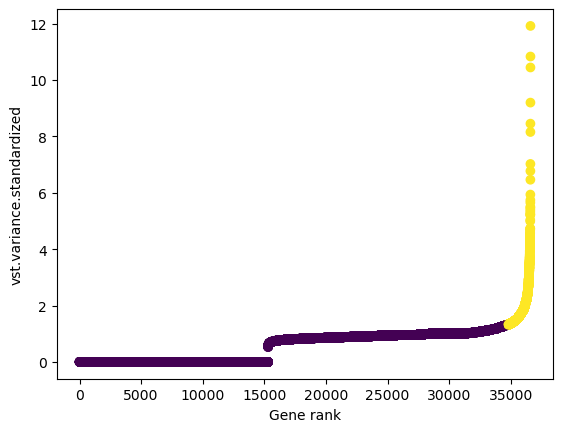

In [24]:
import matplotlib.pyplot as plt
plt.scatter(np.argsort(np.argsort(df_meta_expr["vst.variance.standardized"])), df_meta_expr["vst.variance.standardized"], c = df_meta_expr["vst.variable"])
plt.xlabel("Gene rank"); plt.ylabel("vst.variance.standardized")

In [25]:
qs = np.linspace(0, 0.9, 10)[::-1]
genes = [df_meta_expr.loc[:, "vst.variance.standardized"] > np.quantile(df_meta_expr.loc[:, "vst.variance.standardized"], q) for q in qs] 

In [26]:
for idx, q in zip(genes, qs):
    X_expr_subset.loc[:, idx].to_csv(f"../data/preprocessed{suffix}/X_rna_variance_{q:.2f}.csv")

In [27]:
X_marker_subset.to_csv(f"../data/preprocessed{suffix}/X_adt.csv")

pd.Series(bc_in_expr).to_csv(f"../data/preprocessed{suffix}/barcodes.csv")
pd.Series(timepoints).to_csv(f"../data/preprocessed{suffix}/timepoints.csv")
pd.Series(celltypes).to_csv( f"../data/preprocessed{suffix}/celltypes.csv")

np.save(f"../data/preprocessed{suffix}/X_bc.npy", X)